# PART B - Practical (Python Programming)


**step 1:Measures of central Tendency & Dispersion**
- calculate mean, median, mode of Mathe_Score.
- Find range, variance, standard deviation of science_score.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import skew, kurtosis

In [26]:
df = pd.read_csv('students_scores.csv')
df.head()

,Student_ID,Age,Math_Score,Science_Score,English_Score,Hours_Studied,Pass_Fail
0,S0001,16,14,10,10,0.7,0
1,S0002,16,53,51,60,6.1,1
2,S0003,18,45,44,54,7.3,1
3,S0004,15,72,61,68,7.7,1
4,S0005,20,14,10,12,1.5,0


In [27]:
# Mean , Median, Mode
mean_math = df['Math_Score'].mean()
median_math = df['Math_Score'].median()
mode_math = df['Math_Score'].mode()[0]

print(f'Mean Math Score: {mean_math}')
print(f'Median Math Score: {median_math}')
print(f'Mode Math Score: {mode_math}')

Mean Math Score: 42.1068
Median Math Score: 42.0
Mode Math Score: 10


In [28]:
# range, variance, standard deviation
range_science = df['Science_Score'].max() - df['Science_Score'].min()
variance_science = df['Science_Score'].var()
std_dev_science = df['Science_Score'].std()

print(f"  Min              : {df['Science_Score'].min()}")
print(f"  Max              : {df['Science_Score'].max()}")
print(f"  Range            : {range_science}")
print(f"  Variance         : {variance_science:.2f}")
print(f"  Standard Deviation: {std_dev_science:.2f}")

  Min              : 10
  Max              : 100
  Range            : 90
  Variance         : 458.03
  Standard Deviation: 21.40


**step2: Probability Basics**

- find the probability of students passing (Pass_Fail = 1).
- Create a contingency table between Pass_Fail and Hours_studied > 5.
- Calculate conditional probability: P(Pass | Hours_studied > 5).

In [29]:
total_students = len(df)
total_pass     = df[df["Pass_Fail"] == 1].shape[0]
total_fail     = df[df["Pass_Fail"] == 0].shape[0]

p_pass = total_pass / total_students
p_fail = total_fail / total_students

print(f"  Total Students   : {total_students}")
print(f"  Total Pass (1)   : {total_pass}")
print(f"  Total Fail (0)   : {total_fail}")
print(f"\n  P(Pass)          : {total_pass}/{total_students} = {p_pass:.4f}  ({p_pass*100:.2f}%)")
print(f"  P(Fail)          : {total_fail}/{total_students} = {p_fail:.4f}  ({p_fail*100:.2f}%)")


  Total Students   : 5000
  Total Pass (1)   : 2517
  Total Fail (0)   : 2483

  P(Pass)          : 2517/5000 = 0.5034  (50.34%)
  P(Fail)          : 2483/5000 = 0.4966  (49.66%)


In [30]:
df["High_Study"] = df["Hours_Studied"].apply(lambda x: "Hours > 5" if x > 5 else "Hours ≤ 5")

contingency_table = pd.crosstab(
    df["High_Study"],
    df["Pass_Fail"],
    margins=True,
    margins_name="Total"
)
contingency_table.columns = ['Failed(0)', 'Passed(1)', 'Total']

print(contingency_table)

            Failed(0)  Passed(1)  Total
High_Study                             
Hours > 5         358       2207   2565
Hours ≤ 5        2125        310   2435
Total            2483       2517   5000


In [31]:
high_study_df     = df[df["Hours_Studied"] > 5]
high_study_pass   = high_study_df[high_study_df["Pass_Fail"] == 1].shape[0]
high_study_total  = high_study_df.shape[0]

p_pass_given_high = high_study_pass / high_study_total

print(f"  Students with Hours_Studied > 5   : {high_study_total}")
print(f"  Among them who Passed             : {high_study_pass}")
print(f"\n  P(Pass | Hours_Studied > 5)       : {high_study_pass}/{high_study_total}")
print(f"                                    = {p_pass_given_high:.4f}  ({p_pass_given_high*100:.2f}%)")

print(f"\n  📌 Interpretation:")
print(f"     A student who studied more than 5 hours")
print(f"     has a {p_pass_given_high*100:.1f}% probability of passing —")
print(f"     compared to overall pass rate of {p_pass*100:.1f}%.")


  Students with Hours_Studied > 5   : 2565
  Among them who Passed             : 2207

  P(Pass | Hours_Studied > 5)       : 2207/2565
                                    = 0.8604  (86.04%)

  📌 Interpretation:
     A student who studied more than 5 hours
     has a 86.0% probability of passing —
     compared to overall pass rate of 50.3%.


**Step 3:Distributtion & visualization**

- Plot a Histogram & Normal curve for Math_score.
- Calculate Skewness & Kurtosis for Science_Score.
- Perform a Q-Q Plot for English_Score.

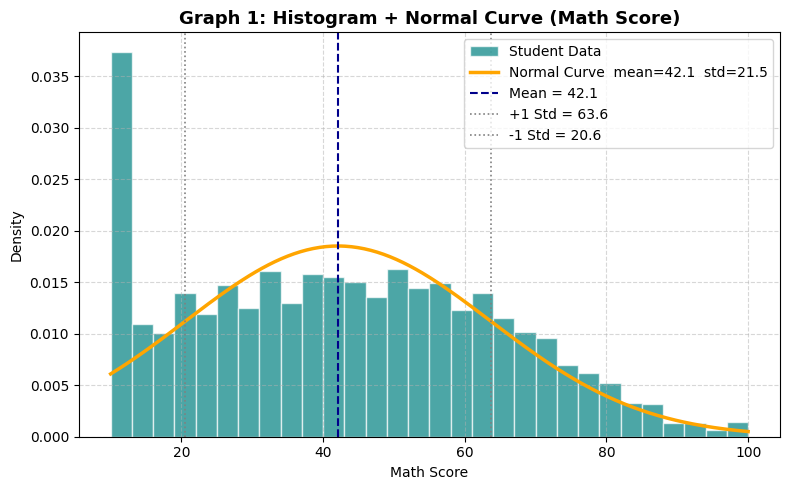

Graph 1 done!


In [ ]:
math_data = df["Math_Score"]
mu    = math_data.mean()
sigma = math_data.std()

plt.figure(figsize=(8, 5))
plt.hist(math_data, bins=30, color="teal", edgecolor="white",
         alpha=0.7, density=True, label="Student Data")

x = np.linspace(math_data.min(), math_data.max(), 300)
plt.plot(x, stats.norm.pdf(x, mu, sigma),
         color="orange", linewidth=2.5,
         label=f"Normal Curve  mean={mu:.1f}  std={sigma:.1f}")

plt.axvline(mu,         color="darkblue", linestyle="--", linewidth=1.5, label=f"Mean = {mu:.1f}")
plt.axvline(mu + sigma, color="gray",     linestyle=":",  linewidth=1.2, label=f"+1 Std = {mu+sigma:.1f}")
plt.axvline(mu - sigma, color="gray",     linestyle=":",  linewidth=1.2, label=f"-1 Std = {mu-sigma:.1f}")

plt.title("Graph 1: Histogram + Normal Curve (Math Score)", fontsize=13, fontweight="bold")
plt.xlabel("Math Score")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
print("Graph 1 done!")

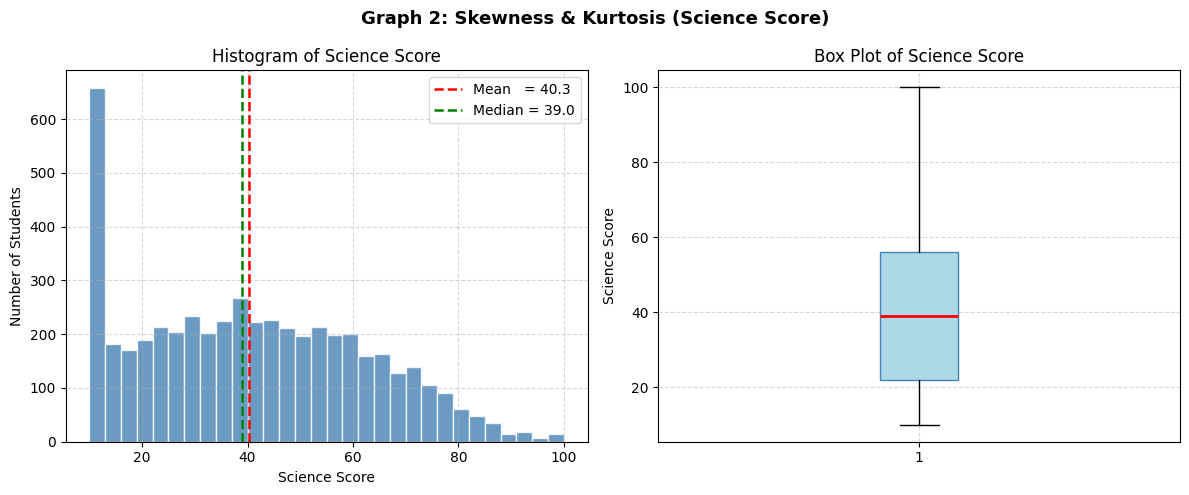

Graph 2 done!
  Skewness = 0.2898
  Kurtosis = -0.8088


In [56]:
sci  = df["Science_Score"]
sk   = skew(sci)
kurt = kurtosis(sci)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Graph 2: Skewness & Kurtosis (Science Score)",
             fontsize=13, fontweight="bold")

axes[0].hist(sci, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(sci.mean(),   color="red",    linestyle="--", linewidth=1.8, label=f"Mean   = {sci.mean():.1f}")
axes[0].axvline(sci.median(), color="green",  linestyle="--", linewidth=1.8, label=f"Median = {sci.median():.1f}")
axes[0].set_title("Histogram of Science Score")
axes[0].set_xlabel("Science Score")
axes[0].set_ylabel("Number of Students")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].boxplot(sci, patch_artist=True,
                boxprops=dict(facecolor="lightblue", color="steelblue"),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Box Plot of Science Score")
axes[1].set_ylabel("Science Score")
axes[1].grid(True, linestyle="--", alpha=0.5)


plt.tight_layout()
plt.show()
print("Graph 2 done!")
print(f"  Skewness = {sk:.4f}")
print(f"  Kurtosis = {kurt:.4f}")

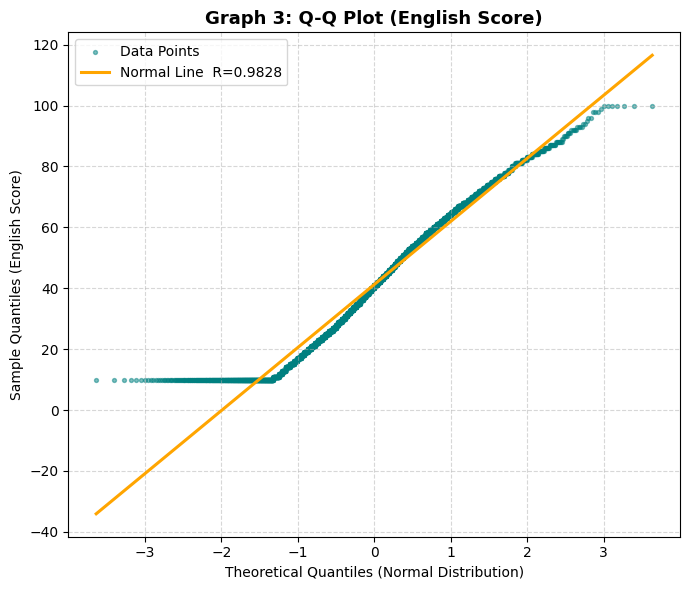

Graph 3 done!
  R value = 0.9828
  English Score is close to Normal Distribution


In [45]:
eng = df["English_Score"]
(theoretical_q, sample_q), (slope, intercept, r) = stats.probplot(eng, dist="norm")

plt.figure(figsize=(7, 6))
plt.scatter(theoretical_q, sample_q,
            color="teal", s=8, alpha=0.5, label="Data Points")
plt.plot(theoretical_q,
         slope * np.array(theoretical_q) + intercept,
         color="orange", linewidth=2.2,
         label=f"Normal Line  R={r:.4f}")

plt.title("Graph 3: Q-Q Plot (English Score)", fontsize=13, fontweight="bold")
plt.xlabel("Theoretical Quantiles (Normal Distribution)")
plt.ylabel("Sample Quantiles (English Score)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
print("Graph 3 done!")
print(f"  R value = {r:.4f}")
print(f"  English Score is {'close to' if r**2 > 0.95 else 'NOT'} Normal Distribution")


**Step 4: Linear Algebra Mini Task**
- Represent Math_Score and Science_Score of first 5 students as vectors.
- perform:

          - Dot product of the two vectors.
          - Norm 1 and Norm 2 of Math_Score vector.
          - Find angle between the two vectors.
          

In [47]:
math_vector    = np.array(df["Math_Score"].head(5))
science_vector = np.array(df["Science_Score"].head(5))

print("\n📌 Vectors (First 5 Students)")
print("-" * 45)
print(f"  Math_Score    Vector : {math_vector}")
print(f"  Science_Score Vector : {science_vector}")


📌 Vectors (First 5 Students)
---------------------------------------------
  Math_Score    Vector : [14 53 45 72 14]
  Science_Score Vector : [10 51 44 61 10]


In [48]:
dot_product = np.dot(math_vector, science_vector)

print("\n📌 Dot Product")
print("-" * 45)
print(f"  Formula  : A · B = Σ(Aᵢ × Bᵢ)")
print(f"  Calculation:")
for i in range(5):
    print(f"    Student {i+1}: {math_vector[i]} × {science_vector[i]} = {math_vector[i] * science_vector[i]}")
print(f"\n  Dot Product Result = {dot_product}")



📌 Dot Product
---------------------------------------------
  Formula  : A · B = Σ(Aᵢ × Bᵢ)
  Calculation:
    Student 1: 14 × 10 = 140
    Student 2: 53 × 51 = 2703
    Student 3: 45 × 44 = 1980
    Student 4: 72 × 61 = 4392
    Student 5: 14 × 10 = 140

  Dot Product Result = 9355


In [ ]:
norm1 = np.linalg.norm(math_vector, ord=1)   
norm2 = np.linalg.norm(math_vector, ord=2)   

print("\n📌 Norm 1 and Norm 2 of Math_Score Vector")
print("-" * 45)
print(f"  Math Vector          : {math_vector}")
print(f"\n  Norm 1 (L1) Formula  : |a1| + |a2| + ... + |an|")
print(f"  Norm 1 (L1) Result   : {norm1:.4f}")
print(f"\n  Norm 2 (L2) Formula  : sqrt(a1² + a2² + ... + an²)")
print(f"  Norm 2 (L2) Result   : {norm2:.4f}")



📌 PART 3: Norm 1 and Norm 2 of Math_Score Vector
---------------------------------------------
  Math Vector          : [14 53 45 72 14]

  Norm 1 (L1) Formula  : |a1| + |a2| + ... + |an|
  Norm 1 (L1) Result   : 198.0000

  Norm 2 (L2) Formula  : sqrt(a1² + a2² + ... + an²)
  Norm 2 (L2) Result   : 102.0294


In [52]:
cos_theta = dot_product / (norm2 * np.linalg.norm(science_vector, ord=2))
angle_rad  = np.arccos(np.clip(cos_theta, -1.0, 1.0))
angle_deg  = np.degrees(angle_rad)

print("\n📌 Angle Between Math & Science Vectors")
print("-" * 45)
print(f"  Formula  : cos(θ) = (A · B) / (||A|| × ||B||)")
print(f"\n  Dot Product          : {dot_product}")
print(f"  ||Math Vector||      : {norm2:.4f}")
print(f"  ||Science Vector||   : {np.linalg.norm(science_vector):.4f}")
print(f"  cos(θ)               : {cos_theta:.4f}")
print(f"\n  Angle in Radians     : {angle_rad:.4f} rad")
print(f"  Angle in Degrees     : {angle_deg:.4f}°")

if angle_deg < 30:
    interpretation = "Vectors are very similar (small angle)"
elif angle_deg < 70:
    interpretation = "Vectors are moderately related"
elif angle_deg == 90:
    interpretation = "Vectors are perpendicular (no relation)"
else:
    interpretation = "Vectors point in different directions"

print(f"\n  Interpretation       : {interpretation}")



📌 Angle Between Math & Science Vectors
---------------------------------------------
  Formula  : cos(θ) = (A · B) / (||A|| × ||B||)

  Dot Product          : 9355
  ||Math Vector||      : 102.0294
  ||Science Vector||   : 91.9674
  cos(θ)               : 0.9970

  Angle in Radians     : 0.0778 rad
  Angle in Degrees     : 4.4572°

  Interpretation       : Vectors are very similar (small angle)


In [53]:
print("\n" + "=" * 55)
print("  SUMMARY")
print("=" * 55)
print(f"  Math_Score Vector    : {math_vector}")
print(f"  Science_Score Vector : {science_vector}")
print(f"  Dot Product          : {dot_product}")
print(f"  Norm 1 (Math)        : {norm1:.4f}")
print(f"  Norm 2 (Math)        : {norm2:.4f}")
print(f"  Angle Between        : {angle_deg:.4f}°")
print("=" * 55)
print("✅ Step 4 Complete!")
print("=" * 55)


  SUMMARY
  Math_Score Vector    : [14 53 45 72 14]
  Science_Score Vector : [10 51 44 61 10]
  Dot Product          : 9355
  Norm 1 (Math)        : 198.0000
  Norm 2 (Math)        : 102.0294
  Angle Between        : 4.4572°
✅ Step 4 Complete!
